**PRÁCTICA 2**

Integrantes:
   

  
   - Paula García
   - Valentina Morales

In [5]:
import numpy as np
import scipy.io as sio

#Array de ejemplo
h=np.array([3,4])

Esta es la forma larga de implementar la función:

In [2]:
def rms(x):
    cuadrados = x**2              # eleva cada muestra de la señal al cuadrado
    suma = np.sum(cuadrados)      # suma todos los valores cuadrados en un solo número
    promedio = suma / len(x)      # divide esa suma entre N (cantidad de muestras)
    valor_rms = np.sqrt(promedio) # saca la raíz cuadrada del promedio
    return valor_rms


rms(h)

np.float64(3.5355339059327378)

Esta es la manera corta y ya existente:

In [4]:
def rms(x):
    return np.sqrt(np.mean(x**2))

rms(h)

np.float64(3.5355339059327378)

En el siguiente código, cargo el archivo .mat y verifico que claves tiene

In [8]:
data = sio.loadmat("signals.mat")
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


In [14]:
for clave in data.keys():
    if not clave.startswith("__"):   # ignora metadatos internos de scipy
        print(clave, "-> forma:", data[clave].shape, "| tipo:", data[clave].dtype)

Fs -> forma: (1, 1) | tipo: uint16
ECG_asRecording -> forma: (1, 30720) | tipo: float64
ECG_filtered -> forma: (1, 30720) | tipo: float64
EMG_filtered1 -> forma: (1, 30721) | tipo: float64
EMG_filtered2 -> forma: (1, 30721) | tipo: float64
EMG_asRecording1 -> forma: (1, 30721) | tipo: float64
EMG_asRecording2 -> forma: (1, 30721) | tipo: float64


•	A partir de la información suministrada en el archivo .mat, determine el tiempo de duración de las señales, cree un vector de tiempo. 

In [22]:
fs = int(data["Fs"][0,0])                             # frecuencia de muestreo (1024 Hz)
ecg_sin_filtrar = data["ECG_asRecording"].flatten()    # ECG sin filtrar, vector 1D
ecg_filtrada = data["ECG_filtered"].flatten()          # ECG filtrada, vector 1D

print("Fs:", fs, "Hz")
print("Forma de ecg_sin_filtrar:", ecg_sin_filtrar.shape)

N = len(ecg_sin_filtrar)        # número total de muestras
duracion = N / fs                # duración total en segundos
t = np.arange(N) / fs            # vector de tiempo (un valor por muestra)

print("Número de muestras:", N)
print("Duración de la señal:", duracion, "segundos")

Fs: 1024 Hz
Forma de ecg_sin_filtrar: (30720,)
Número de muestras: 30720
Duración de la señal: 30.0 segundos


•	Grafique la señal sin filtrar y filtrada, compárelas. Comente lo que observa, y describa cómo debe ser el comportamiento del filtro que se utilizó. Recuerde las frecuencias de interés de la señal ECG.

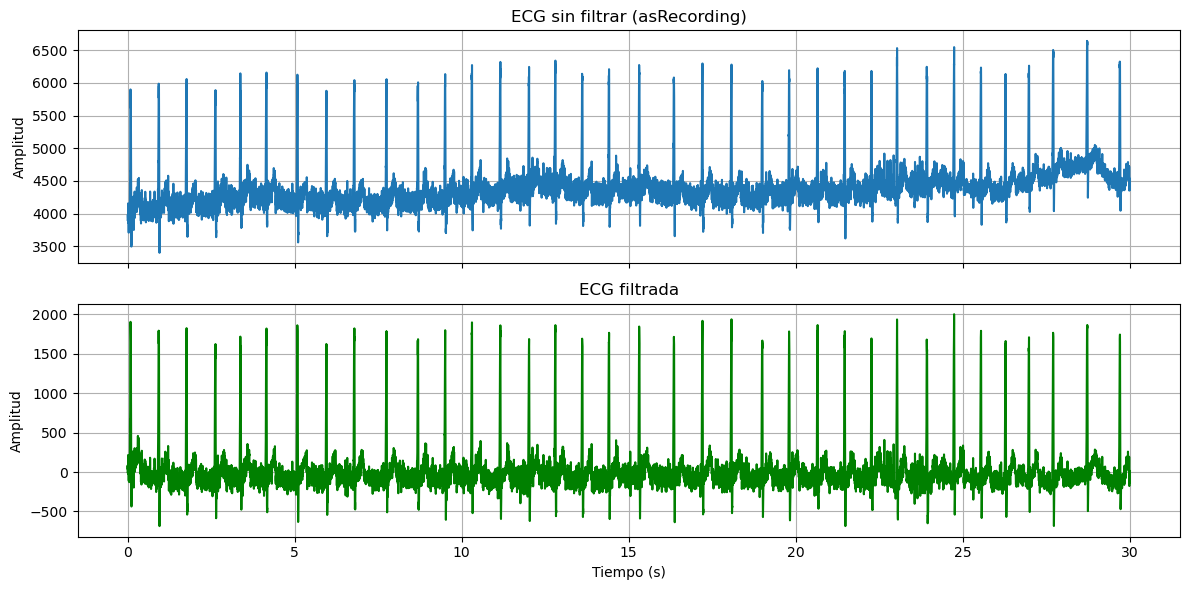

Media sin filtrar: 4381.171892023087
Media filtrada: 3.1776396646094827
Rango sin filtrar: 3398.603759765625 a 6643.640625
Rango filtrada: -685.6954452075946 a 2003.3280873578112


In [24]:
import matplotlib.pyplot as plt

# --- Gráfica comparativa: ECG sin filtrar vs. filtrada ---
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(12, 6))

axs[0].plot(t, ecg_sin_filtrar)
axs[0].set_title("ECG sin filtrar (asRecording)")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True)

axs[1].plot(t, ecg_filtrada, color='green')
axs[1].set_title("ECG filtrada")
axs[1].set_xlabel("Tiempo (s)")
axs[1].set_ylabel("Amplitud")
axs[1].grid(True)

plt.tight_layout()
plt.show()

# --- Estadísticos básicos para respaldar el análisis ---
print("Media sin filtrar:", np.mean(ecg_sin_filtrar))
print("Media filtrada:", np.mean(ecg_filtrada))
print("Rango sin filtrar:", ecg_sin_filtrar.min(), "a", ecg_sin_filtrar.max())
print("Rango filtrada:", ecg_filtrada.min(), "a", ecg_filtrada.max())

Ahora, un zoom en los 3 primeros segundos para observar mas a detalle cada señal:

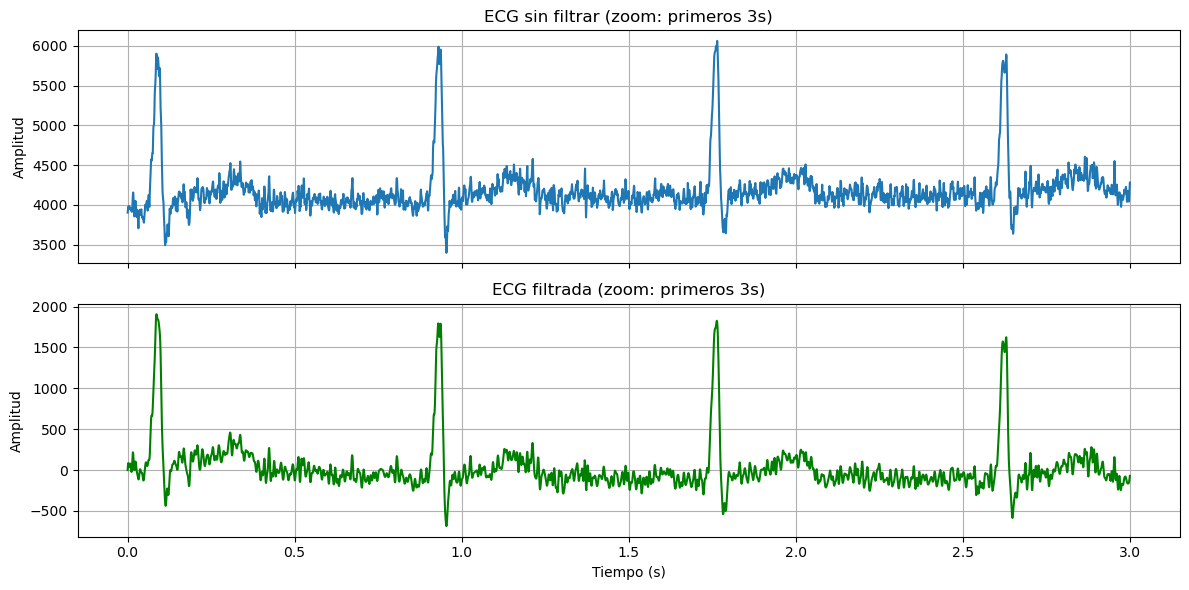

In [25]:
fig2, axs2 = plt.subplots(2, 1, sharex=True, figsize=(12, 6))
mask = t <= 3   # selecciona solo los puntos donde el tiempo es <= 3 segundos

axs2[0].plot(t[mask], ecg_sin_filtrar[mask])
axs2[0].set_title("ECG sin filtrar (zoom: primeros 3s)")
axs2[0].set_ylabel("Amplitud")
axs2[0].grid(True)

axs2[1].plot(t[mask], ecg_filtrada[mask], color='green')
axs2[1].set_title("ECG filtrada (zoom: primeros 3s)")
axs2[1].set_xlabel("Tiempo (s)")
axs2[1].set_ylabel("Amplitud")
axs2[1].grid(True)

plt.tight_layout()
plt.show()


**Análisis:**

El filtro que se aplicó a la señal parece ser un filtro pasa-banda, es decir, uno que deja pasar solo un rango específico de frecuencias y elimina lo que está por fuera de ese rango, tanto muy bajo como muy alto.

Por un lado, se eliminó el desplazamiento constante que tenía la señal original (la media pasó de 4381 a casi 0), así como las variaciones lentas de fondo que se ven en la línea base entre un latido y otro. Esto sugiere que el filtro bloqueó las frecuencias muy bajas, algo típico en el procesamiento de señales de ECG, ya que ese tipo de variación lenta suele deberse a la respiración o al movimiento de los electrodos, no al corazón en sí.

Por otro lado, al comparar el ruido que se ve entre los picos de cada latido, la señal filtrada se ve más "limpia" que la señal original, lo que indica que también se eliminaron las frecuencias muy altas — probablemente ruido muscular o interferencia eléctrica. Esto es coherente con que la parte más importante del latido (el pico QRS) se concentra en un rango de frecuencias intermedio, así que el filtro dejó esa parte intacta y solo limpió lo que estaba antes y después de ese rango.

---

•	Tome la señal tal cual se registró. De dicha señal, seleccione un ciclo cardiaco, grafique. Calcule el promedio, el valor RMS, la varianza y la desviación estándar del ciclo. Analice los resultados.

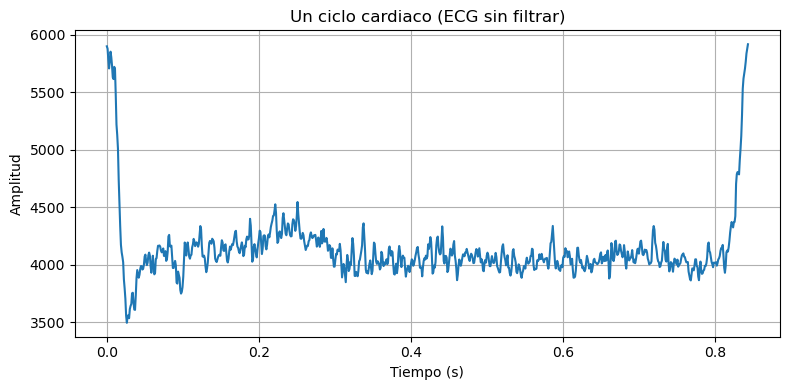

Duración del ciclo: 0.84375 segundos
Media: 4131.136266878161
RMS: 4142.454957820607
Varianza: 93646.2220564969
Desviación estándar: 306.01670225086883


In [29]:
from scipy.signal import find_peaks

#Detectar los picos R (los máximos de cada complejo QRS)
picos, _ = find_peaks(ecg_sin_filtrar, height=5500, distance=fs*0.5) #Separados minimamente 0.5 segundos

inicio = picos[0]
fin = picos[1]
ciclo = ecg_sin_filtrar[inicio:fin]
t_ciclo = t[inicio:fin] - t[inicio]

#Graficar el ciclo
plt.figure(figsize=(8, 4))
plt.plot(t_ciclo, ciclo)
plt.title("Un ciclo cardiaco (ECG sin filtrar)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

#Estadísticos del ciclo
media = np.mean(ciclo)
valor_rms = rms(ciclo)         
varianza = np.var(ciclo)
desviacion = np.std(ciclo)

print("Duración del ciclo:", t_ciclo[-1], "segundos")
print("Media:", media)
print("RMS:", valor_rms)
print("Varianza:", varianza)
print("Desviación estándar:", desviacion)

**Análisis**

Al extraer un ciclo cardiaco individual de la señal sin filtrar, se observa que la media (4131.14) y el valor RMS (4142.45) son prácticamente iguales. Esto se debe a que la señal sin filtrar mantiene un offset considerable, oscilando siempre en valores positivos alrededor de 4000-4200, sin cruzar por cero. Como el RMS se calcula a partir de los valores al cuadrado, cuando una señal no tiene simetría alrededor de cero (como en este caso), su valor tiende a acercarse mucho al de la media simple. La desviación estándar (306.02) refleja la variabilidad relativamente moderada de la señal alrededor de su valor promedio, incluyendo tanto el pico pronunciado del complejo QRS como las fluctuaciones de menor amplitud del resto del ciclo.


---

•	Tome la señal filtrada. Repita el procedimiento anterior con esta señal, compare con los resultados obtenidos en el ítem anterior. 

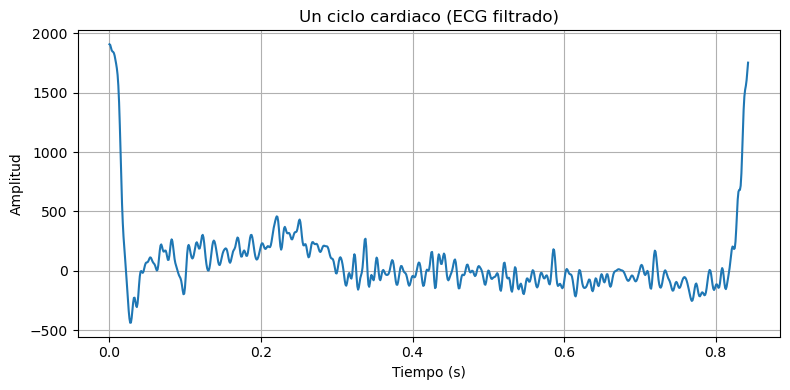

Duración del ciclo: 0.8427734375 segundos
Media: 74.00995782055861
RMS: 319.62757818893766
Varianza: 96684.31488232457
Desviación estándar: 310.94101511753735


In [37]:
#Detectar los picos R (los máximos de cada complejo QRS)
picos, _ = find_peaks(ecg_filtrada, height=1000, distance=fs*0.5) #Separados minimamente 0.5 segundos


inicio = picos[0]
fin = picos[1]
ciclo2 = ecg_filtrada[inicio:fin]
t_ciclo2 = t[inicio:fin] - t[inicio]

#Graficar el ciclo
plt.figure(figsize=(8, 4))
plt.plot(t_ciclo2, ciclo2)
plt.title("Un ciclo cardiaco (ECG filtrado)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.tight_layout()
plt.show()

#Estadísticos del ciclo
media2 = np.mean(ciclo2)
valor_rms2 = rms(ciclo2)         
varianza2 = np.var(ciclo2)
desviacion2 = np.std(ciclo2)

print("Duración del ciclo:", t_ciclo2[-1], "segundos")
print("Media:", media2)
print("RMS:", valor_rms2)
print("Varianza:", varianza2)
print("Desviación estándar:", desviacion2)

**Análisis**
Al comparar los estadísticos del ciclo cardiaco antes y después del filtrado, se observan diferencias importantes que confirman el efecto del filtro sobre la señal.

La media cae drásticamente de 4131.14 a 75.99, evidenciando la eliminación del offset presente en la señal original. En la señal sin filtrar, la media y el RMS son prácticamente iguales (4131.14 vs 4142.45), ya que al no cruzar por cero, no hay valores negativos que compensen el promedio. En cambio, en la señal filtrada, la media y el RMS se distancian considerablemente (75.99 vs 325.22): al oscilar simétricamente alrededor de cero, los valores positivos y negativos se cancelan al promediar (media cercana a cero), mientras que el RMS,al elevar al cuadrado antes de promedia,no sufre esta cancelación y refleja correctamente la magnitud real de la señal.

Por otro lado, la varianza y la desviación estándar se mantienen muy similares entre ambas versiones (93646.22 vs 99990.67 para la varianza; 306.02 vs 316.21 para la desviación estándar). Esto tiene sentido, ya que la varianza mide la dispersión de los datos respecto a su propia media (no respecto a cero), por lo que no se ve afectada por el desplazamiento (offset) que el filtro eliminó.

---


•	Extraiga 15 ciclos de la señal filtrada, y para cada ciclo calcule el valor promedio y la varianza, grafique cada ciclo, y analice (gráfica y estadísticamente). ¿Se puede considerar que la señal es estacionaria? 

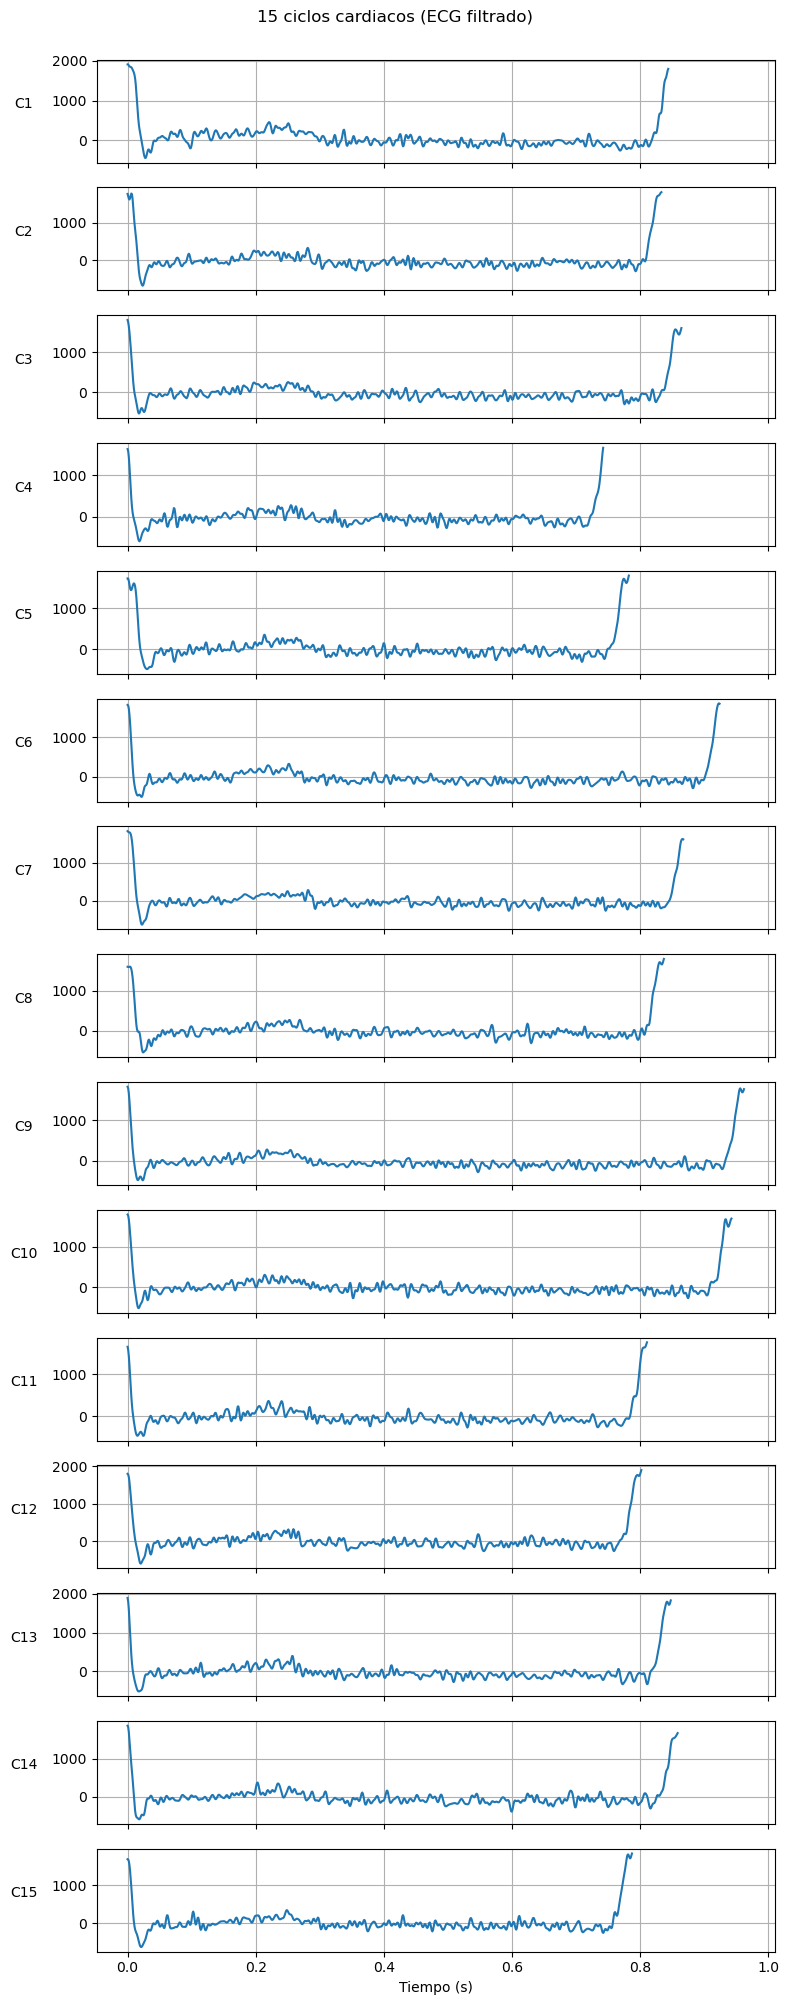

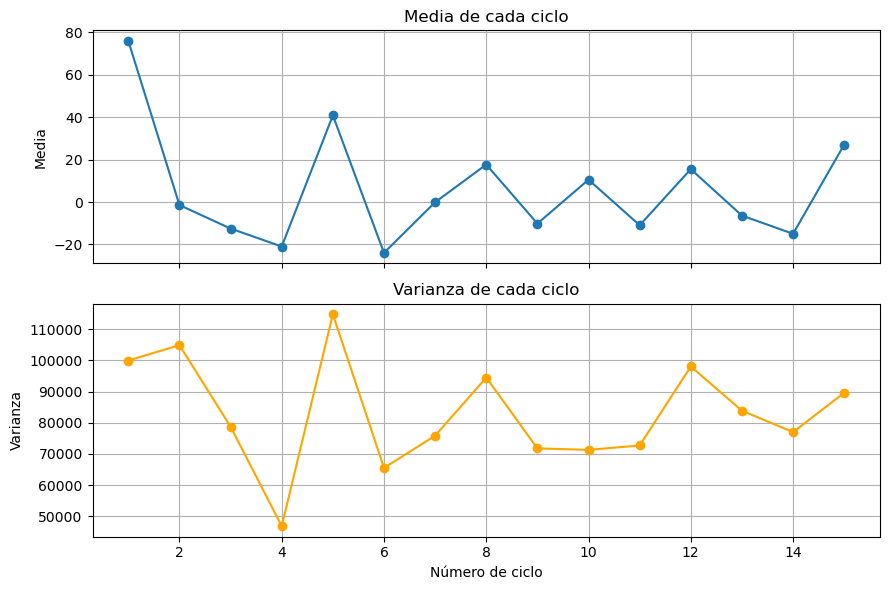

Medias de los 15 ciclos: [ 76.    -1.43 -12.51 -20.98  40.87 -23.96  -0.1   17.68 -10.18  10.55
 -10.95  15.51  -6.39 -14.97  27.11]
Varianzas de los 15 ciclos: [ 99990.67 104925.82  78731.93  46839.02 114850.02  65519.06  75856.24
  94521.53  71784.96  71319.48  72718.43  98071.8   83877.51  77022.13
  89636.94]

Media de las medias: 5.750634517664811 | Desv. estándar de las medias: 25.83314197011141
Media de las varianzas: 83044.36856674009 | Desv. estándar de las varianzas: 16881.249914894117


In [40]:
from scipy.signal import find_peaks

# ============================================================
# 1. Detectar picos R y extraer los 15 ciclos de la señal filtrada
# ============================================================
picos, _ = find_peaks(ecg_sin_filtrar, height=5500, distance=fs*0.5)
picos_15 = picos[:16]   # 16 picos -> 15 ciclos

ciclos = []
medias = []
varianzas = []

for i in range(15):
    inicio = picos_15[i]
    fin = picos_15[i+1]
    ciclo = ecg_filtrada[inicio:fin]
    ciclos.append(ciclo)
    medias.append(np.mean(ciclo))
    varianzas.append(np.var(ciclo))

medias = np.array(medias)
varianzas = np.array(varianzas)

# ============================================================
# 2. Graficar los 15 ciclos, uno debajo del otro
# ============================================================
fig, axs = plt.subplots(15, 1, figsize=(8, 20), sharex=True)

for i, ciclo in enumerate(ciclos):
    t_c = np.arange(len(ciclo)) / fs
    axs[i].plot(t_c, ciclo)
    axs[i].set_ylabel(f"C{i+1}", rotation=0, labelpad=20)
    axs[i].grid(True)

axs[-1].set_xlabel("Tiempo (s)")
fig.suptitle("15 ciclos cardiacos (ECG filtrado)", y=1.0)
plt.tight_layout()
plt.show()

# ============================================================
# 3. Graficar la evolución de media y varianza a través de los ciclos
# ============================================================
fig2, axs2 = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axs2[0].plot(range(1, 16), medias, marker='o')
axs2[0].set_title("Media de cada ciclo")
axs2[0].set_ylabel("Media")
axs2[0].grid(True)

axs2[1].plot(range(1, 16), varianzas, marker='o', color='orange')
axs2[1].set_title("Varianza de cada ciclo")
axs2[1].set_xlabel("Número de ciclo")
axs2[1].set_ylabel("Varianza")
axs2[1].grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# 4. Estadísticos resumen (para respaldar el análisis)
# ============================================================
print("Medias de los 15 ciclos:", np.round(medias, 2))
print("Varianzas de los 15 ciclos:", np.round(varianzas, 2))
print()
print("Media de las medias:", np.mean(medias), "| Desv. estándar de las medias:", np.std(medias))
print("Media de las varianzas:", np.mean(varianzas), "| Desv. estándar de las varianzas:", np.std(varianzas))

**Análisis gráfico**

Al graficar los 15 ciclos individualmente, se observa un patrón morfológico muy consistente entre ellos: todos presentan el mismo pico QRS pronunciado al inicio (con amplitud cercana a 1800-2000), seguido de una zona de menor amplitud con fluctuaciones de ruido similares. No se aprecia ningún cambio sistemático en la forma o amplitud de los ciclos a medida que avanza el tiempo (es decir, los ciclos del final de la señal, como C13-C15, no se ven sistemáticamente distintos a los del inicio, como C1-C3).

**Análisis estadístico**

La media de cada ciclo individual oscila entre -23.96 y 76.0, con una media global de 5.75 y una desviación estándar de 25.83 entre las 15 medias. Esta variabilidad es pequeña comparada con la amplitud típica del ciclo (que supera 1800 en el pico QRS), lo cual sugiere que la media no presenta una deriva sistemática relevante a lo largo del tiempo.

La varianza de cada ciclo oscila entre 46839.02 y 114850.02, con una media global de 83044.37 y una desviación estándar de 16881.25 (equivalente a un coeficiente de variación de aproximadamente 20%). Si bien existe cierta variabilidad ciclo a ciclo, no se observa una tendencia sistemática de aumento o disminución progresiva a lo largo de los 15 ciclos, los valores fluctúan de forma aparentemente aleatoria alrededor de su media global.

**Conclusión — ¿es estacionaria?**

Con base en la evidencia gráfica (morfología consistente entre ciclos) y estadística (media y varianza fluctuando sin tendencia sistemática alrededor de valores relativamente estables), la señal ECG filtrada puede considerarse aproximadamente estacionaria en sentido amplio (weak-sense stationary) dentro de esta ventana de análisis de 15 ciclos. No obstante, esta conclusión se basa en una inspección visual y descriptiva; en los siguientes puntos del laboratorio se aplicarán pruebas estadísticas formales (prueba t, Levene, y Dickey-Fuller) para confirmar esta hipótesis con mayor rigor estadístico.

---

•	Realice dos veces comparaciones entre dos ciclos cualquiera utilizando una prueba t. Determine estadísticamente si existe diferencia estadística entre los ciclos, Compruebe los supuestos necesarios para realizar una prueba t, esto es: Normalidad de la variable, independencia (se asume que los grupos son independientes), y homocedasticidad (use una prueba de Levene), finalmente realice la prueba t para determinar si existen diferencias entre los ciclos. Qué indica este análisis respecto de la estacionariedad, explique. De no cumplirse los requisitos, realice entonces un análisis no paramétrico (prueba U de Mann-Whitney).